In [125]:
import seaborn as sns

# Load the built-in titanic dataset
df = sns.load_dataset('titanic')

# Display the first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# Da fare

- ripulire il dataset
- convertire categorie in numeri
- rimuovere outlier con z-score 3
- feature engineering
- normalizzare
- applicare logistic regression

In [126]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [127]:
# Conta dei valori mancanti per colonna
print(df.isnull().sum() / len(df) * 100)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [128]:
# 1Elimina la colonna 'deck'
df = df.drop(columns=['deck'])

# 2Riempi i valori nulli della colonna 'age' con la mediana
df['age'].fillna(df['age'].mean(), inplace=True)

# 3Elimina le righe dove 'embarked' è nullo
df = df.dropna(subset=['embarked'])

# Controllo finale dei valori nulli
print(df.isnull().sum())

# Mostra le prime righe pulite
print(df.head())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True 

C:\Users\elisabetta\AppData\Local\Temp\ipykernel_28880\3398712807.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


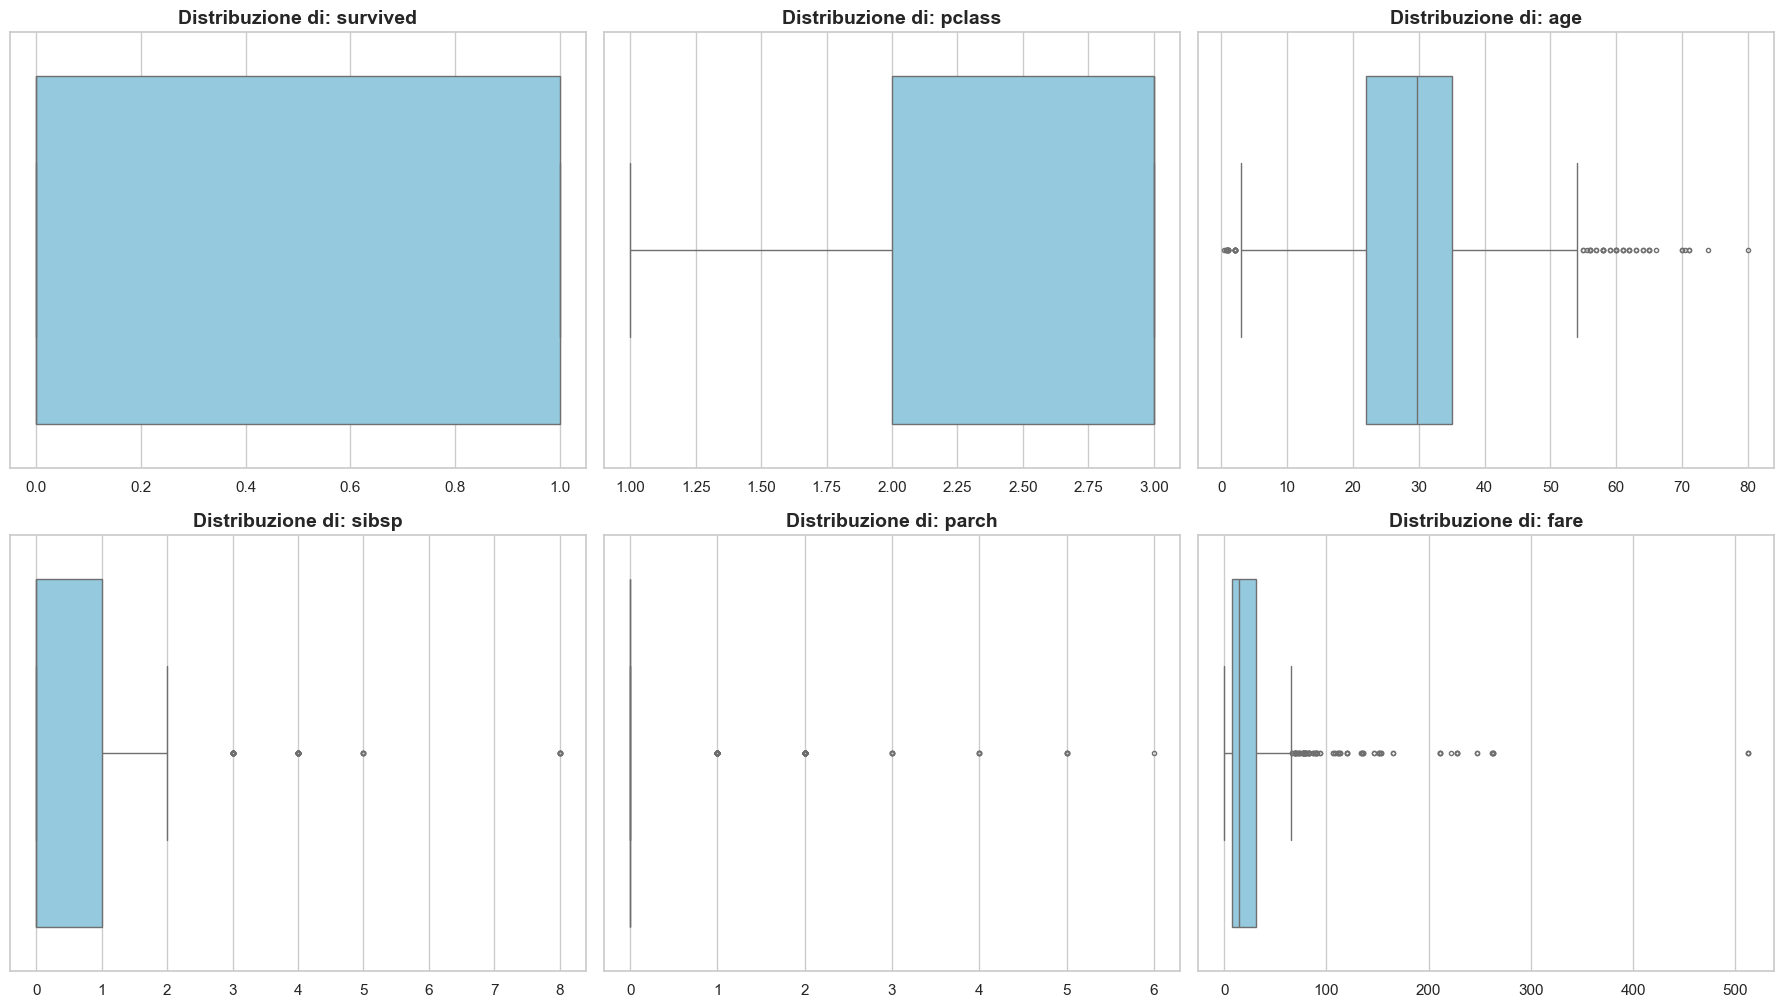

In [129]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

In [130]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione

df = remove_outliers_zscore(df, ['age', 'fare', 'parch', 'sibsp'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df)}")



Righe rimosse con Z-Score: 0


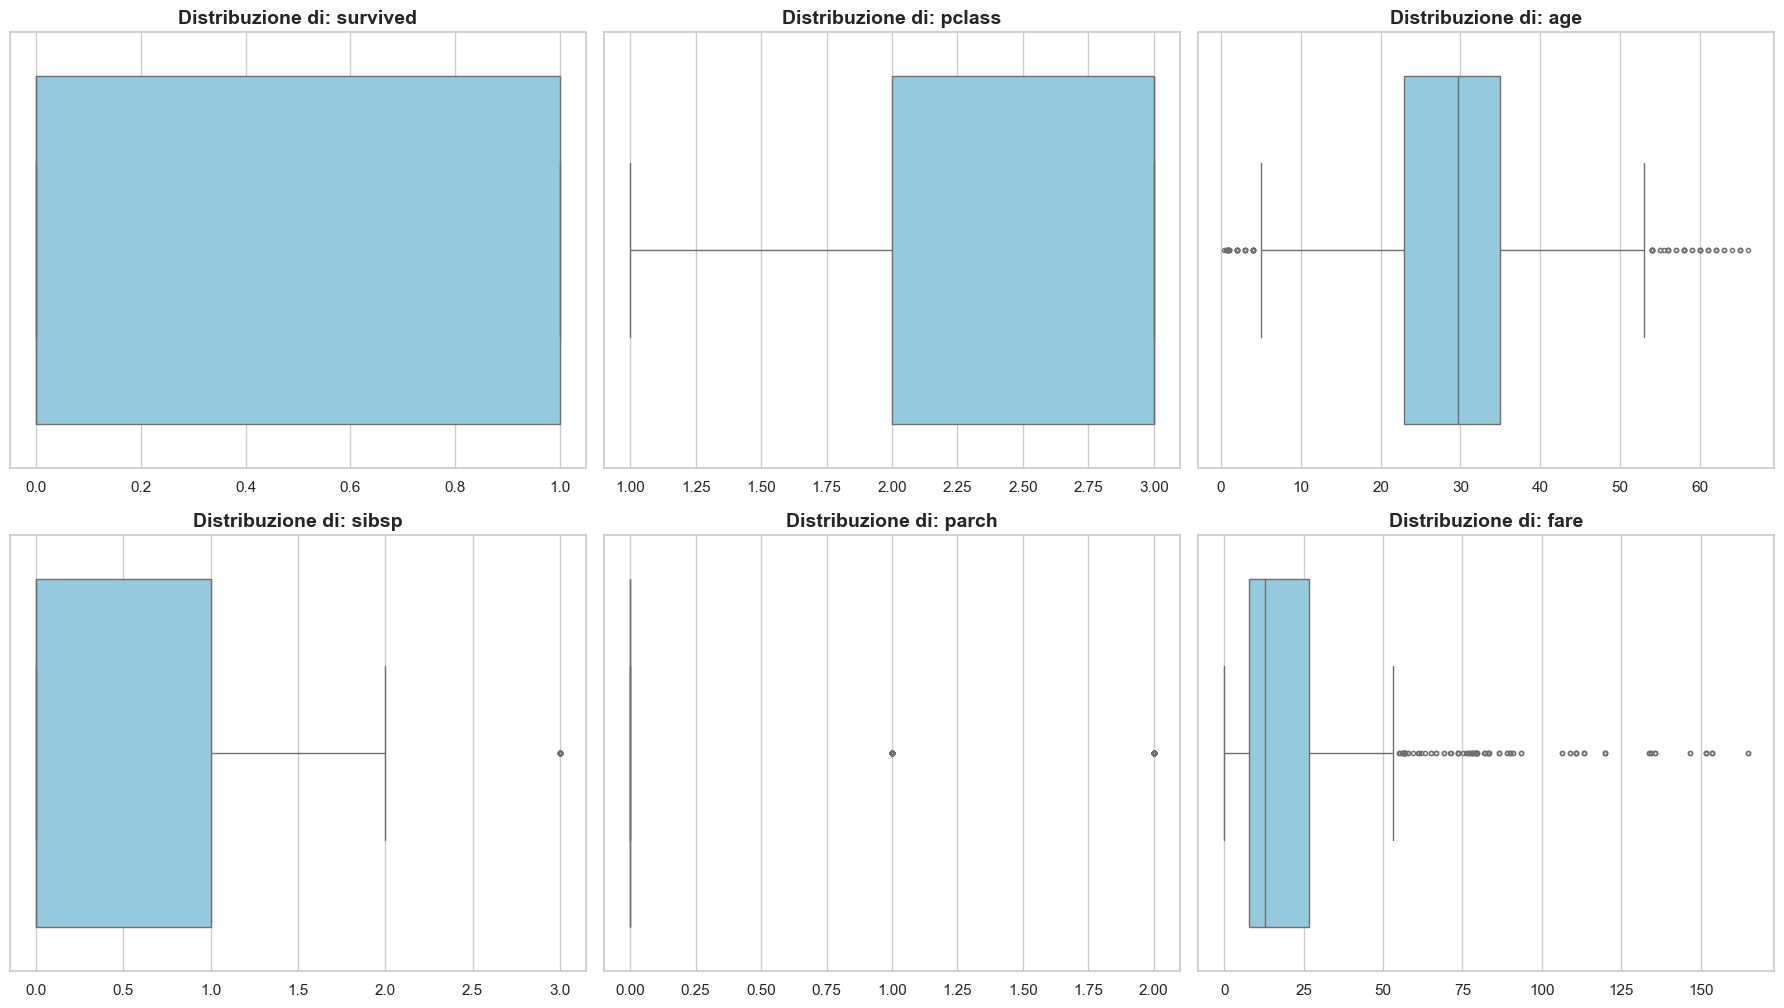

In [131]:
sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

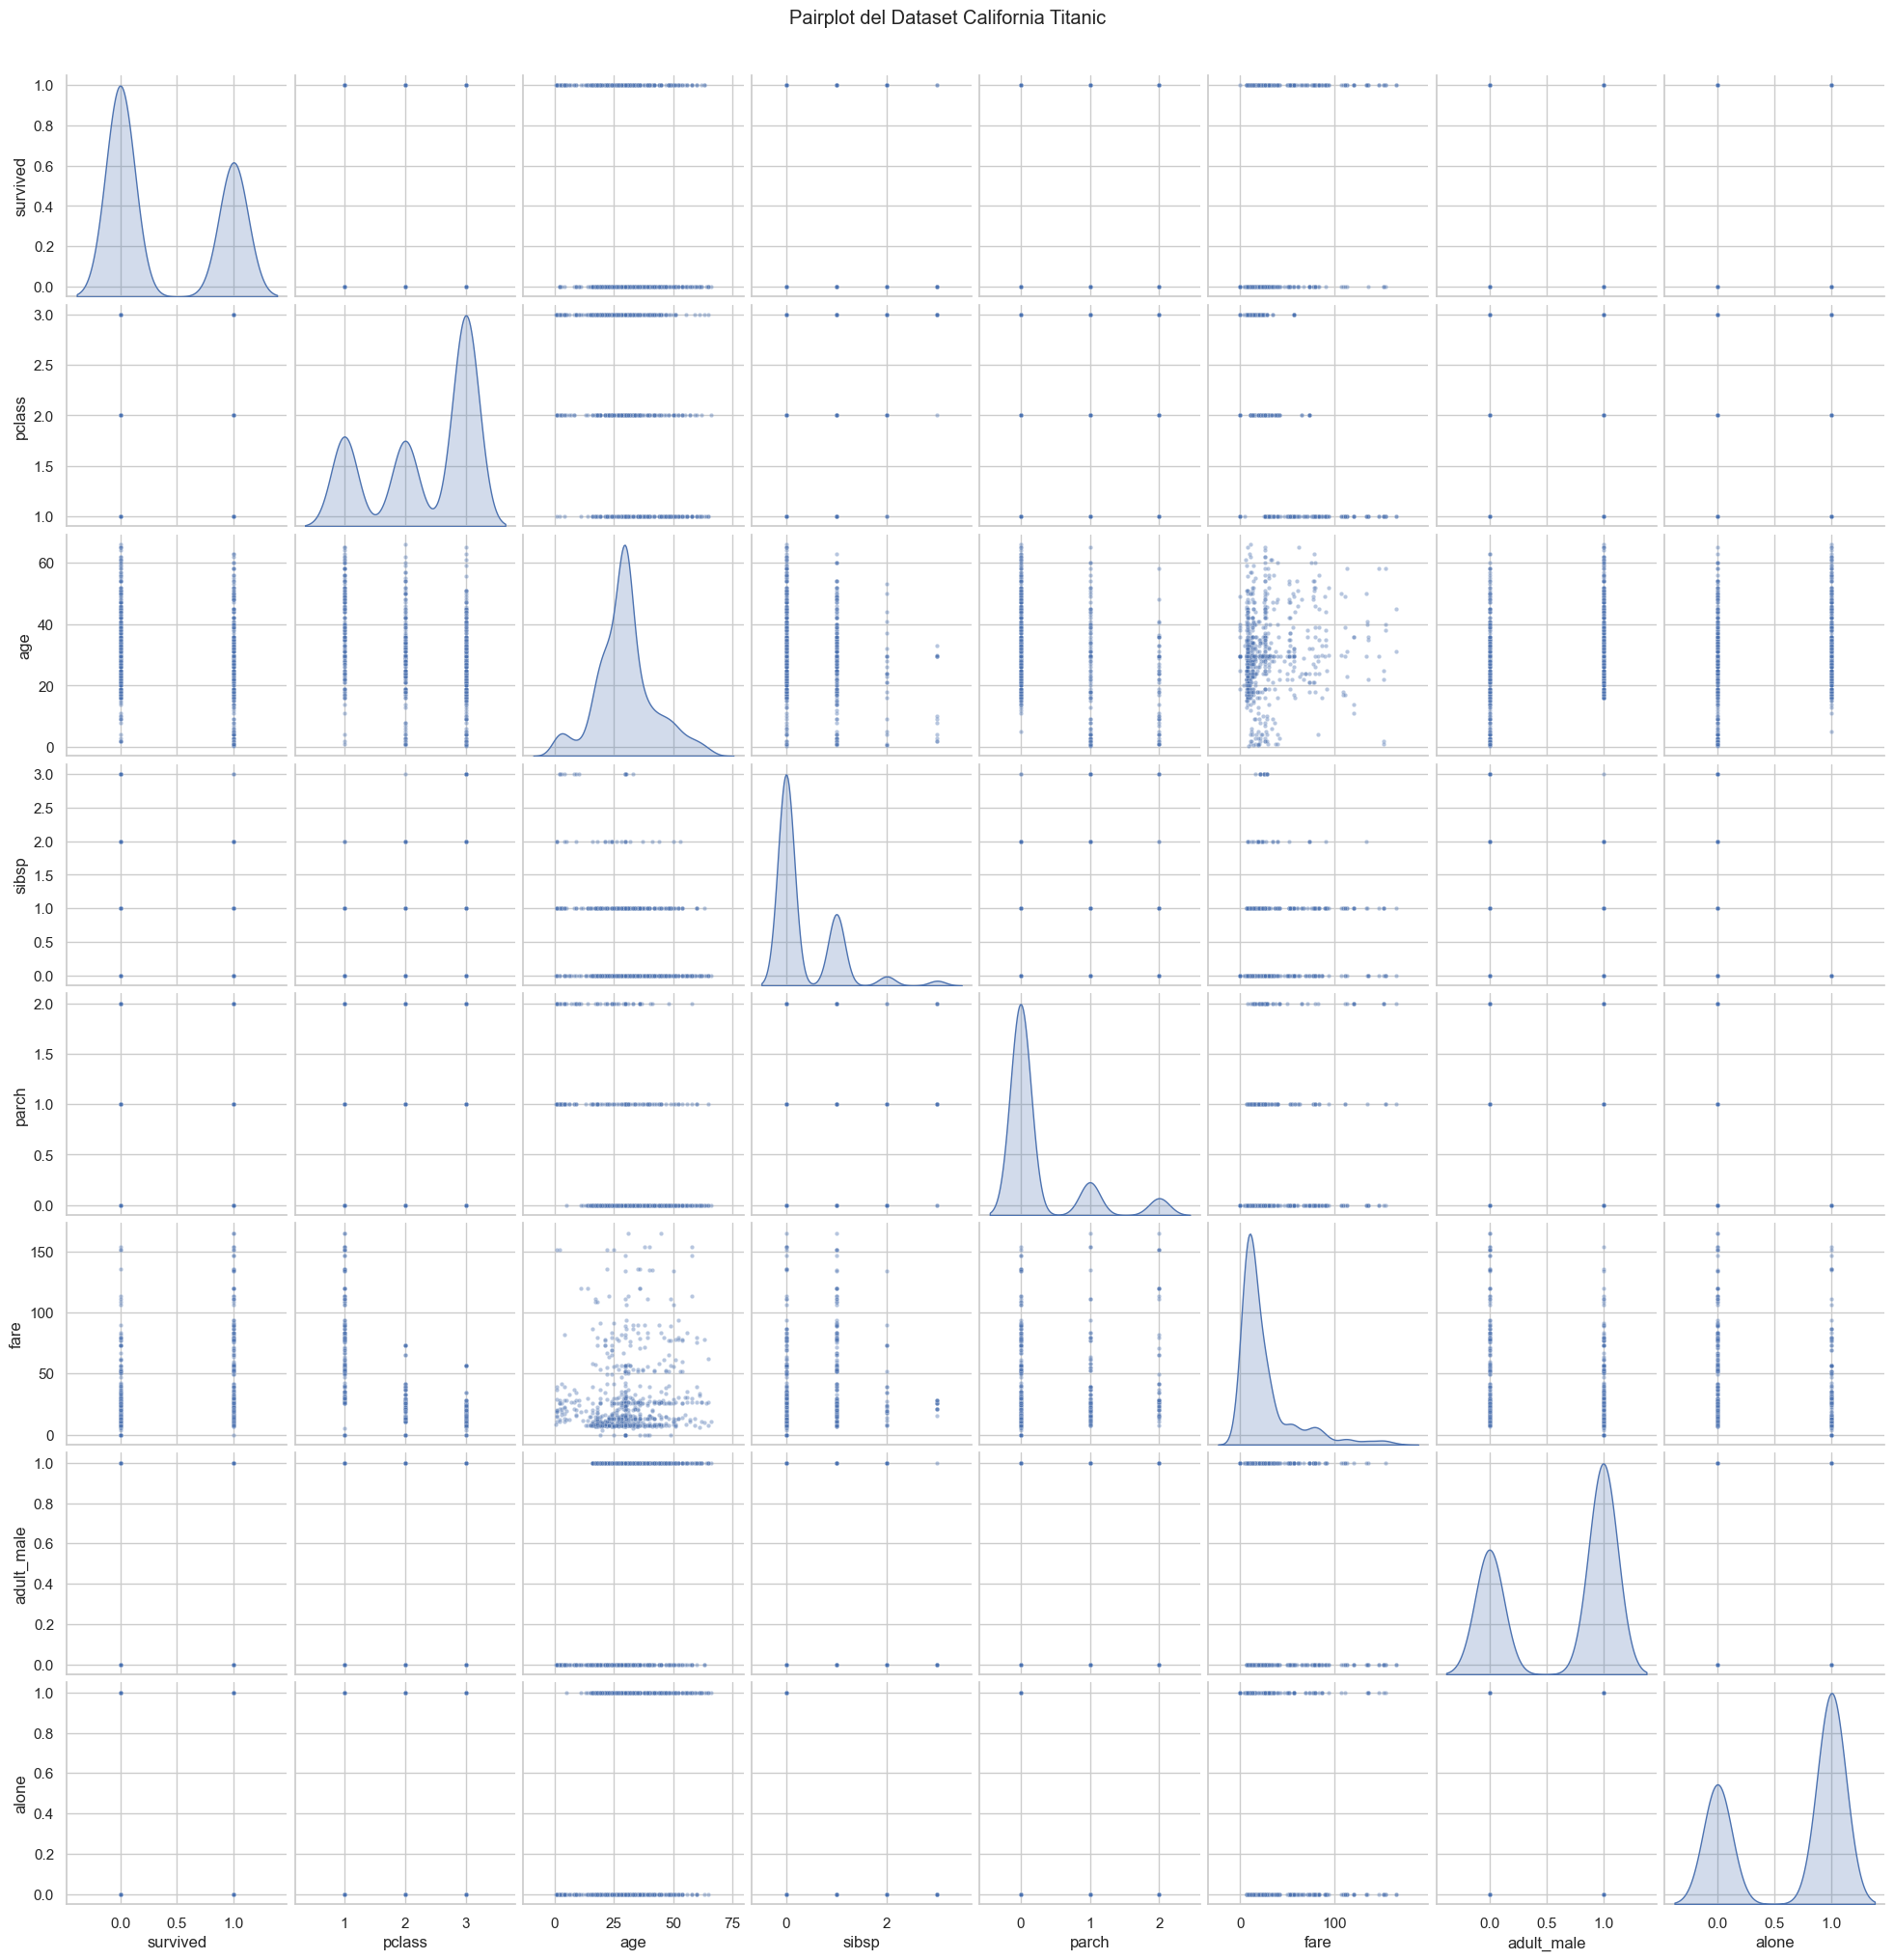

In [132]:
# Campionamento per velocità e chiarezza (es. 1000 righe)
##df = df.sample(n=, random_state=42)

# Creazione del Pairplot
# 'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
# 'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Titanic", y=1.02)
plt.show()

In [ ]:
# feature enginnering
# Famiglia totale (sibsp + parch + se stesso)
df['family_size'] = df['sibsp'] + df['parch'] + 1

df['age_log'] = np.log1p(df['age'])
df['fare_log'] = np.log1p(df['fare'])

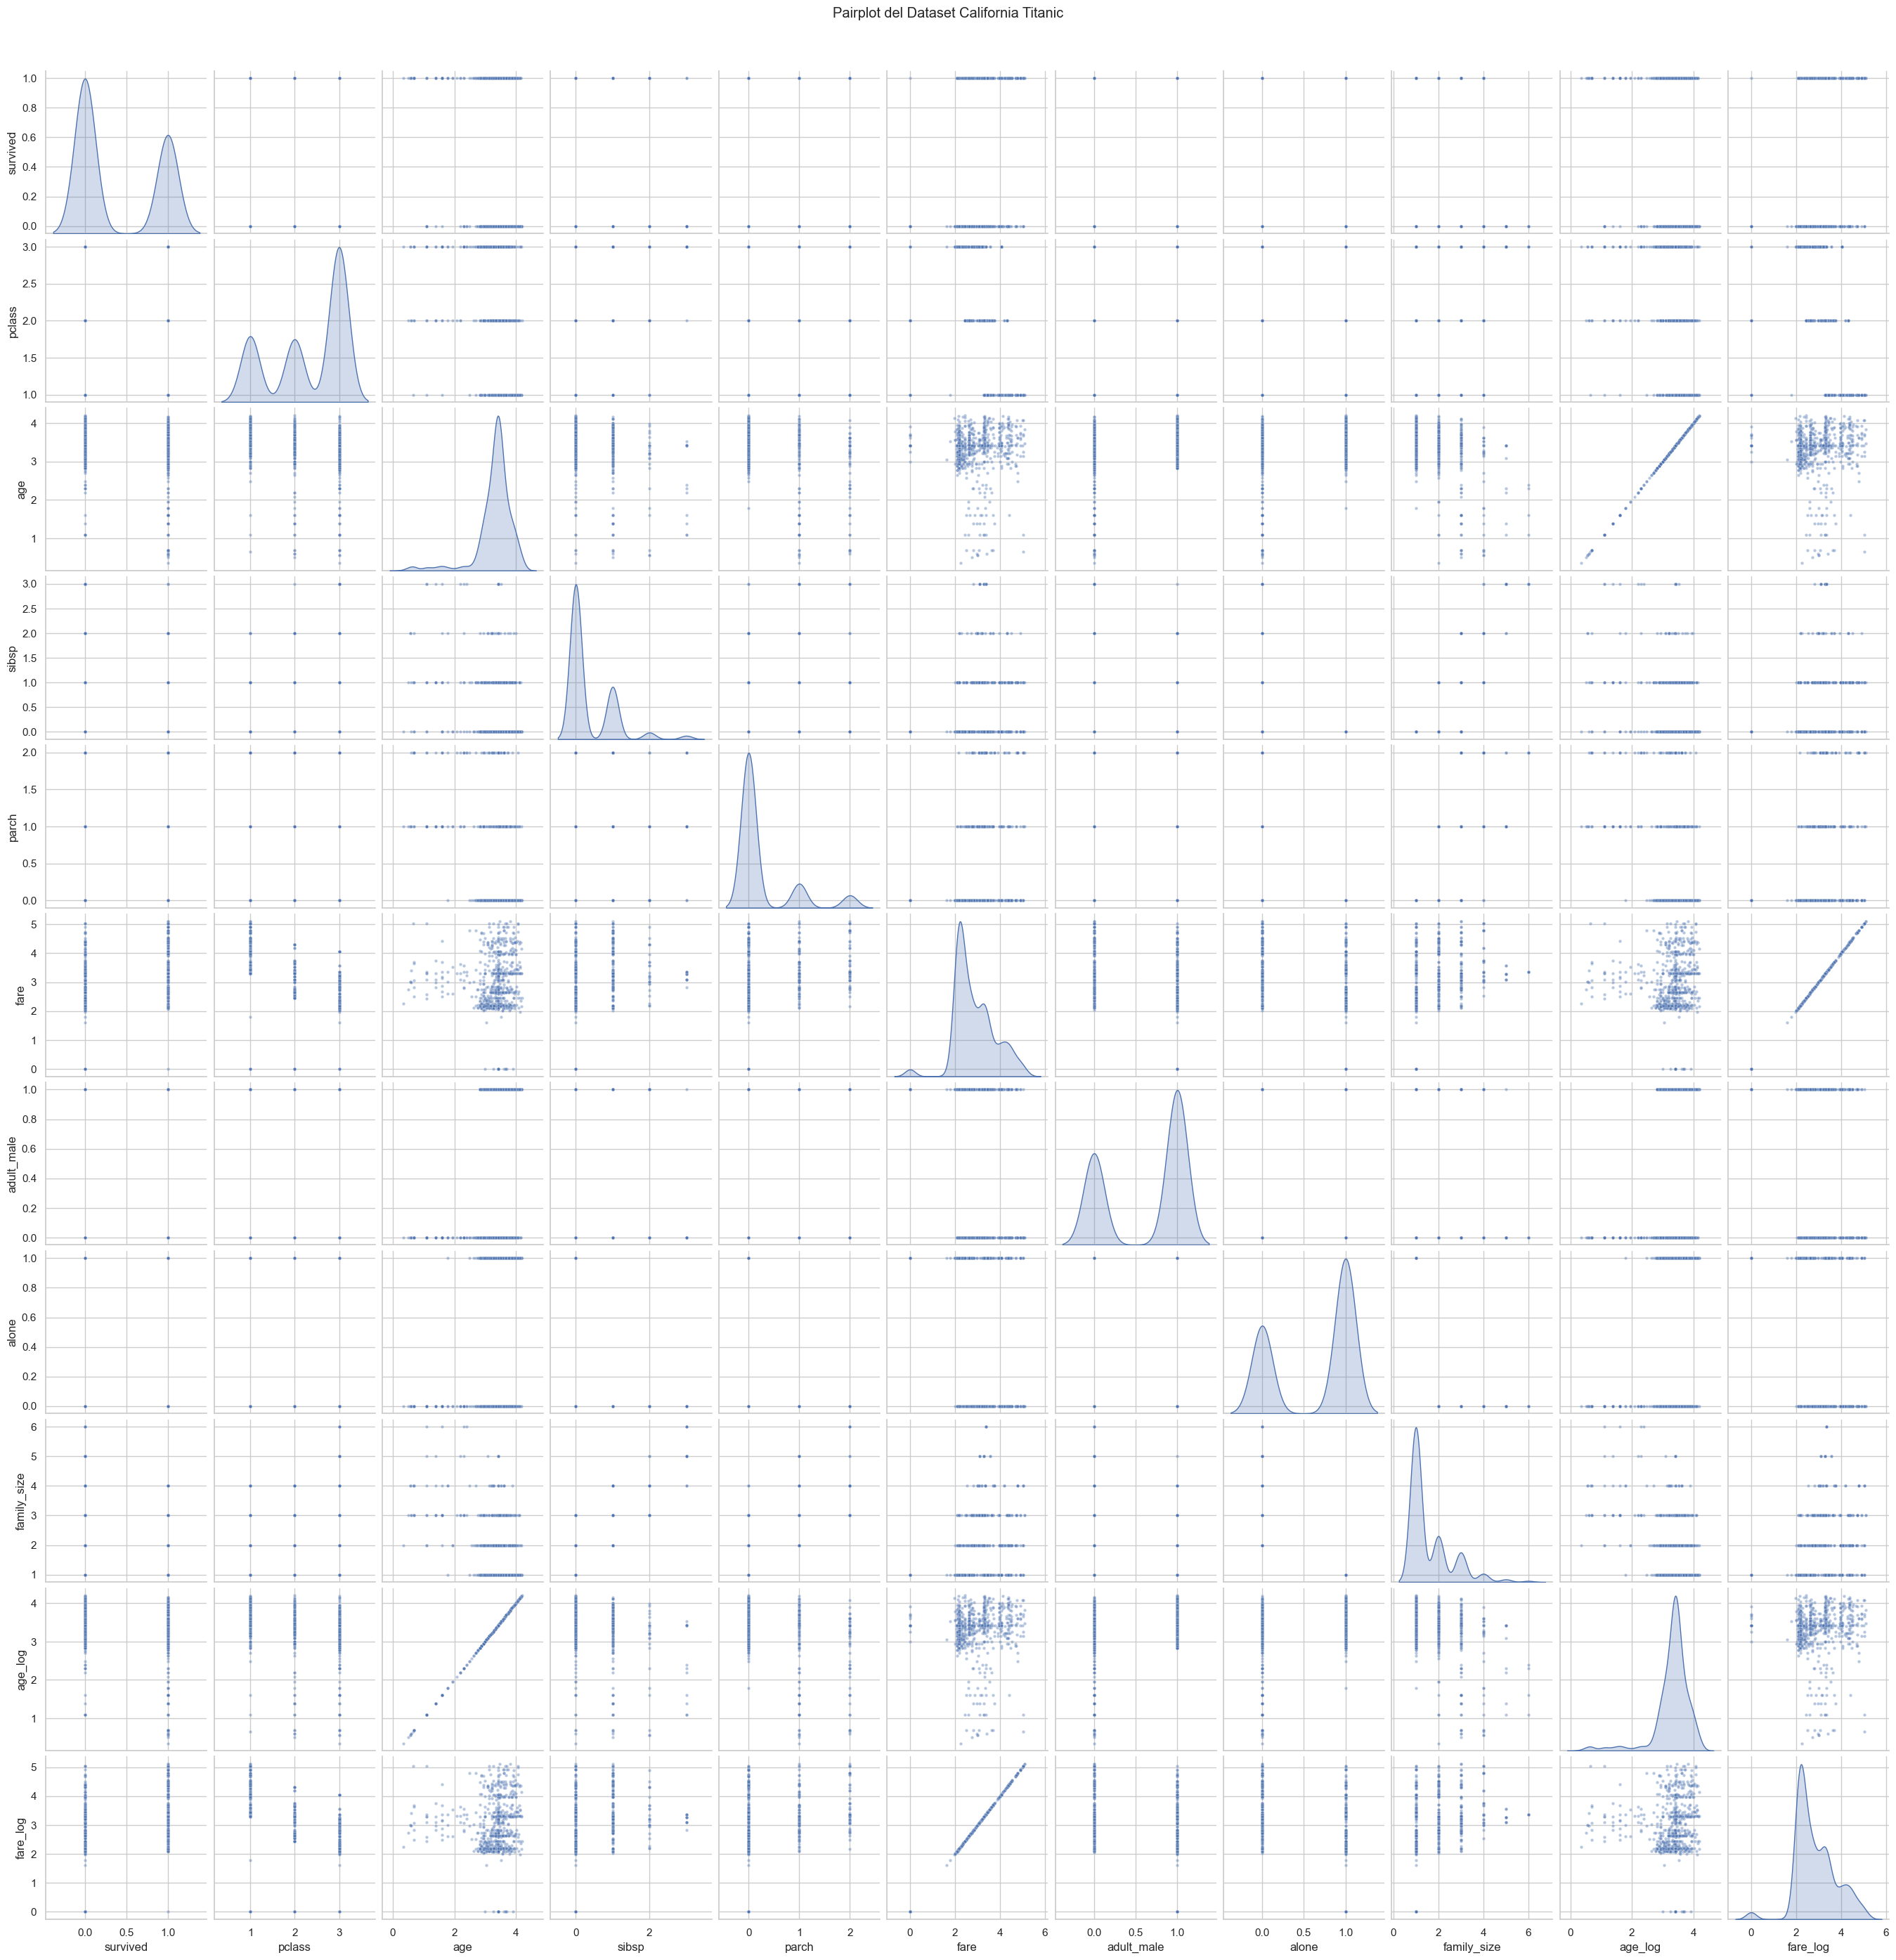

In [141]:
sns.pairplot(df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Titanic", y=1.02)
plt.show()

In [ ]:
## encoding variab categoriche
import pandas as pd

# Variabili categoriche da trasformare
categorical_cols = ['sex', 'class', 'embarked', 'who']

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [136]:
# standard scaler
from sklearn.preprocessing import StandardScaler

# Colonne numeriche da normalizzare
#num_cols = ['age', 'fare_log', 'sibsp_log', 'parch_log', 'family_size_log']
num_cols = ['age', 'fare_log', 'sibsp', 'parch', 'family_size']


scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Rimuovo colonne non numeriche inutili
#embark_town → stringa, ridondante
#alive → ridondante rispetto a survived
df_encoded = df_encoded.drop(columns=['embark_town', 'alive'])


In [137]:
from sklearn.model_selection import train_test_split

# Target
y = df_encoded['survived']

# Feature ['age', 'fare_log', 'sibsp', 'parch', 'family_size', 'adult_male', 'alone','sex_male', 'class_Second', 'class_Third','embarked_Q', 'embarked_S','who_man', 'who_woman']
X = df_encoded.drop(columns=['survived'])

# Split train/test (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Creiamo il modello
logreg = LogisticRegression(max_iter=1000)  # max_iter alto per assicurare convergenza
print(X_train.dtypes)
# Alleniamo il modello
logreg.fit(X_train, y_train)

# Previsioni
y_pred = logreg.predict(X_test)

pclass            int64
age             float64
sibsp           float64
parch           float64
fare            float64
adult_male         bool
alone              bool
family_size     float64
age_log         float64
fare_log        float64
sex_male           bool
class_Second       bool
class_Third        bool
embarked_Q         bool
embarked_S         bool
who_man            bool
who_woman          bool
dtype: object


In [139]:
# Accuratezza
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Matrice di confusione
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Report dettagliato
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8293
Confusion Matrix:
[[92 12]
 [16 44]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       104
           1       0.79      0.73      0.76        60

    accuracy                           0.83       164
   macro avg       0.82      0.81      0.81       164
weighted avg       0.83      0.83      0.83       164



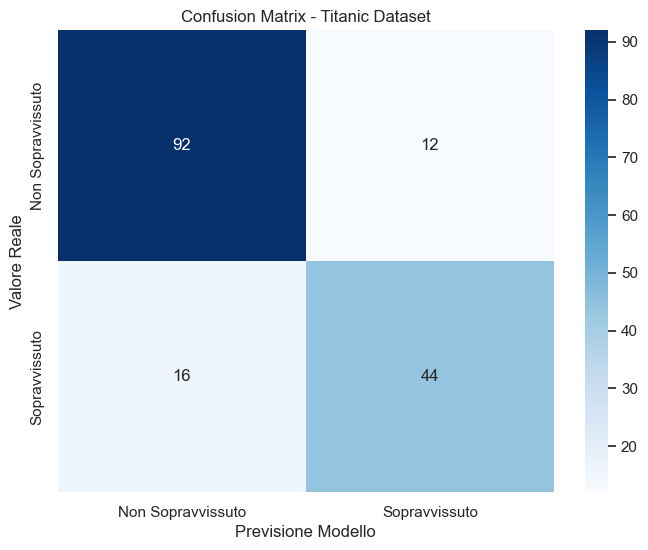

In [146]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
# 5. Plot con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non Sopravvissuto', 'Sopravvissuto'], 
            yticklabels=['Non Sopravvissuto', 'Sopravvissuto'])

plt.xlabel('Previsione Modello')
plt.ylabel('Valore Reale')
plt.title('Confusion Matrix - Titanic Dataset')
plt.show()